# 🧮 Homogeneous Functions, Euler's Theorem & Multivariable Taylor Series

**Objective:** To identify homogeneous functions, verify Euler's Theorem, and compute Taylor series for multivariable functions.

---

## 📦 Install & Import Required Libraries

In [1]:
# Install sympy if not available (already available in Colab)
# !pip install sympy

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, simplify, factor, expand, series, Function, latex
from sympy import sin, cos, exp, log, sqrt, tan
from IPython.display import display, Math

# Define common symbols
x, y, z, t, h, k = symbols('x y z t h k')
n = symbols('n', positive=True)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


---
# 🔷 PART 1: Homogeneous Functions & Euler's Theorem

## 📖 Theory

**Homogeneous Function:**  
A function $f(x, y)$ is called **homogeneous of degree $n$** if:
$$f(tx, ty) = t^n \cdot f(x, y) \quad \forall \; t > 0$$

**Euler's Theorem:**  
If $f(x, y)$ is homogeneous of degree $n$, then:
$$x \frac{\partial f}{\partial x} + y \frac{\partial f}{\partial y} = n \cdot f(x, y)$$

---

## 🔹 Step 1: Check if a Function is Homogeneous

In [2]:
def check_homogeneity(f, x, y, max_degree=6):
    """
    Check if function f(x, y) is homogeneous.
    Returns the degree if homogeneous, else returns None.
    """
    f_scaled = f.subs([(x, t*x), (y, t*y)])
    f_scaled = simplify(f_scaled)

    for degree in range(-max_degree, max_degree + 1):
        ratio = simplify(f_scaled - t**degree * f)
        if ratio == 0:
            return degree
    return None


# ── Example 1: f(x, y) = x² + xy + y² ──
f1 = x**2 + x*y + y**2
degree1 = check_homogeneity(f1, x, y)

print("Example 1: f(x, y) = x² + xy + y²")
display(Math(r'f(x,y) = ' + sp.latex(f1)))
if degree1 is not None:
    print(f"  ✅ Homogeneous of degree: {degree1}")
else:
    print("  ❌ Not Homogeneous")

print()

# ── Example 2: f(x, y) = x³ + y³ / (x + y) ──
f2 = (x**3 + y**3) / (x + y)
degree2 = check_homogeneity(f2, x, y)

print("Example 2: f(x, y) = (x³ + y³) / (x + y)")
display(Math(r'f(x,y) = ' + sp.latex(f2)))
if degree2 is not None:
    print(f"  ✅ Homogeneous of degree: {degree2}")
else:
    print("  ❌ Not Homogeneous")

print()

# ── Example 3: f(x, y) = x² + y (non-homogeneous) ──
f3 = x**2 + y
degree3 = check_homogeneity(f3, x, y)

print("Example 3: f(x, y) = x² + y")
display(Math(r'f(x,y) = ' + sp.latex(f3)))
if degree3 is not None:
    print(f"  ✅ Homogeneous of degree: {degree3}")
else:
    print("  ❌ Not Homogeneous")

Example 1: f(x, y) = x² + xy + y²


<IPython.core.display.Math object>

  ✅ Homogeneous of degree: 2

Example 2: f(x, y) = (x³ + y³) / (x + y)


<IPython.core.display.Math object>

  ✅ Homogeneous of degree: 2

Example 3: f(x, y) = x² + y


<IPython.core.display.Math object>

  ❌ Not Homogeneous


## 🔹 Step 2: Compute Partial Derivatives

In [3]:
def compute_partial_derivatives(f, x, y):
    """Compute and display partial derivatives of f(x, y)."""
    df_dx = diff(f, x)
    df_dy = diff(f, y)

    print("Partial Derivatives:")
    display(Math(r'\frac{\partial f}{\partial x} = ' + sp.latex(simplify(df_dx))))
    display(Math(r'\frac{\partial f}{\partial y} = ' + sp.latex(simplify(df_dy))))

    return df_dx, df_dy


# Use f1 = x² + xy + y²
print("f(x, y) = x² + xy + y²")
print("-" * 35)
df1_dx, df1_dy = compute_partial_derivatives(f1, x, y)

f(x, y) = x² + xy + y²
-----------------------------------
Partial Derivatives:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 🔹 Step 3: Verify Euler's Theorem

In [4]:
def verify_eulers_theorem(f, x, y):
    """
    Verify Euler's theorem: x*df/dx + y*df/dy = n*f
    """
    degree = check_homogeneity(f, x, y)

    if degree is None:
        print("❌ Function is NOT homogeneous. Euler's theorem does not apply.")
        return

    df_dx = diff(f, x)
    df_dy = diff(f, y)

    # LHS: x*∂f/∂x + y*∂f/∂y
    LHS = simplify(x * df_dx + y * df_dy)

    # RHS: n * f
    RHS = simplify(degree * f)

    # Check if LHS == RHS
    difference = simplify(LHS - RHS)

    print(f"Degree of homogeneity (n) = {degree}")
    display(Math(r'\text{LHS} = x\frac{\partial f}{\partial x} + y\frac{\partial f}{\partial y} = ' + sp.latex(LHS)))
    display(Math(r'\text{RHS} = n \cdot f = ' + sp.latex(RHS)))

    if difference == 0:
        print("✅ Euler's Theorem VERIFIED: LHS = RHS")
    else:
        print("❌ Euler's Theorem NOT satisfied (check function).")


# ── Verify for f1 ──
print("═" * 50)
print("f₁(x, y) = x² + xy + y²")
print("═" * 50)
verify_eulers_theorem(f1, x, y)

print()

# ── Verify for f2 ──
print("═" * 50)
print("f₂(x, y) = (x³ + y³) / (x + y)")
print("═" * 50)
verify_eulers_theorem(f2, x, y)

print()

# ── Verify for f3 (non-homogeneous) ──
print("═" * 50)
print("f₃(x, y) = x² + y  (Non-homogeneous)")
print("═" * 50)
verify_eulers_theorem(f3, x, y)

══════════════════════════════════════════════════
f₁(x, y) = x² + xy + y²
══════════════════════════════════════════════════
Degree of homogeneity (n) = 2


<IPython.core.display.Math object>

<IPython.core.display.Math object>

✅ Euler's Theorem VERIFIED: LHS = RHS

══════════════════════════════════════════════════
f₂(x, y) = (x³ + y³) / (x + y)
══════════════════════════════════════════════════
Degree of homogeneity (n) = 2


<IPython.core.display.Math object>

<IPython.core.display.Math object>

✅ Euler's Theorem VERIFIED: LHS = RHS

══════════════════════════════════════════════════
f₃(x, y) = x² + y  (Non-homogeneous)
══════════════════════════════════════════════════
❌ Function is NOT homogeneous. Euler's theorem does not apply.


## 🔹 Step 4: Euler's Theorem for Three Variables

In [5]:
def verify_eulers_theorem_3var(f, x, y, z):
    """
    Verify Euler's theorem for f(x, y, z):
    x*∂f/∂x + y*∂f/∂y + z*∂f/∂z = n*f
    """
    # Check homogeneity
    f_scaled = f.subs([(x, t*x), (y, t*y), (z, t*z)])
    f_scaled = simplify(f_scaled)

    degree = None
    for d in range(-6, 7):
        if simplify(f_scaled - t**d * f) == 0:
            degree = d
            break

    if degree is None:
        print("❌ Not homogeneous — Euler's theorem doesn't apply.")
        return

    df_dx = diff(f, x)
    df_dy = diff(f, y)
    df_dz = diff(f, z)

    LHS = simplify(x*df_dx + y*df_dy + z*df_dz)
    RHS = simplify(degree * f)

    print(f"Degree of homogeneity (n) = {degree}")
    display(Math(r'\text{LHS} = ' + sp.latex(LHS)))
    display(Math(r'\text{RHS} = ' + sp.latex(RHS)))

    if simplify(LHS - RHS) == 0:
        print("✅ Euler's Theorem VERIFIED for 3 variables!")
    else:
        print("❌ Euler's Theorem NOT satisfied.")


# Example: f(x,y,z) = x³ + y³ + z³ + xyz
f4 = x**3 + y**3 + z**3 + x*y*z
print("f(x, y, z) = x³ + y³ + z³ + xyz")
print("═" * 45)
verify_eulers_theorem_3var(f4, x, y, z)

f(x, y, z) = x³ + y³ + z³ + xyz
═════════════════════════════════════════════
Degree of homogeneity (n) = 3


<IPython.core.display.Math object>

<IPython.core.display.Math object>

✅ Euler's Theorem VERIFIED for 3 variables!


---
# 🔷 PART 2: Multivariable Taylor Series

## 📖 Theory

The **Taylor series** of $f(x, y)$ around the point $(a, b)$ is:

$$f(x, y) = \sum_{m=0}^{\infty} \sum_{n=0}^{\infty} \frac{(x-a)^m (y-b)^n}{m! \; n!} \frac{\partial^{m+n} f}{\partial x^m \partial y^n}\Bigg|_{(a,b)}$$

For expansion around $(0, 0)$ (Maclaurin series):
$$f(x, y) \approx f(0,0) + xf_x + yf_y + \frac{1}{2}(x^2 f_{xx} + 2xy f_{xy} + y^2 f_{yy}) + \cdots$$

---

## 🔹 Step 1: Taylor Series Using SymPy

In [6]:
def multivariable_taylor(f, x, y, a=0, b=0, order=3):
    """
    Compute Taylor series of f(x,y) around (a, b) up to given order.
    Uses substitution: x -> a + h, y -> b + k, expand in h and k.
    """
    # Substitute x = a + h, y = b + k
    f_shifted = f.subs([(x, a + h), (y, b + k)])

    # Build Taylor polynomial by collecting terms up to given order
    taylor_poly = sp.Integer(0)
    for total_order in range(order + 1):
        for m in range(total_order + 1):
            n_val = total_order - m
            coeff = diff(f, x, m, y, n_val).subs([(x, a), (y, b)])
            term = coeff * (x - a)**m * (y - b)**n_val / (sp.factorial(m) * sp.factorial(n_val))
            taylor_poly += term

    taylor_poly = expand(taylor_poly)
    return taylor_poly


# ── Example 1: f(x, y) = e^(x+y) ──
f_exp = exp(x + y)
T_exp = multivariable_taylor(f_exp, x, y, a=0, b=0, order=3)

print("Example 1: f(x, y) = e^(x+y)")
print("Taylor expansion around (0, 0) up to order 3:")
display(Math(r'T(x,y) = ' + sp.latex(T_exp)))
print()

# ── Example 2: f(x, y) = sin(x) * cos(y) ──
f_sincos = sin(x) * cos(y)
T_sincos = multivariable_taylor(f_sincos, x, y, a=0, b=0, order=4)

print("Example 2: f(x, y) = sin(x)·cos(y)")
print("Taylor expansion around (0, 0) up to order 4:")
display(Math(r'T(x,y) = ' + sp.latex(T_sincos)))

Example 1: f(x, y) = e^(x+y)
Taylor expansion around (0, 0) up to order 3:


<IPython.core.display.Math object>


Example 2: f(x, y) = sin(x)·cos(y)
Taylor expansion around (0, 0) up to order 4:


<IPython.core.display.Math object>

## 🔹 Step 2: Taylor Series Around a Non-Origin Point

In [7]:
# ── f(x, y) = ln(x + y) around (1, 1) ──
f_ln = log(x + y)
T_ln = multivariable_taylor(f_ln, x, y, a=1, b=1, order=2)

print("f(x, y) = ln(x + y) — Taylor expansion around (1, 1) up to order 2:")
display(Math(r'T(x,y) = ' + sp.latex(expand(T_ln))))

print()

# ── f(x, y) = x * y around (1, 1) ──
f_xy = x * y
T_xy = multivariable_taylor(f_xy, x, y, a=1, b=1, order=2)

print("f(x, y) = xy — Taylor expansion around (1, 1) up to order 2:")
display(Math(r'T(x,y) = ' + sp.latex(expand(T_xy))))

f(x, y) = ln(x + y) — Taylor expansion around (1, 1) up to order 2:


<IPython.core.display.Math object>


f(x, y) = xy — Taylor expansion around (1, 1) up to order 2:


<IPython.core.display.Math object>

## 🔹 Step 3: Error Analysis — Exact vs Approximation

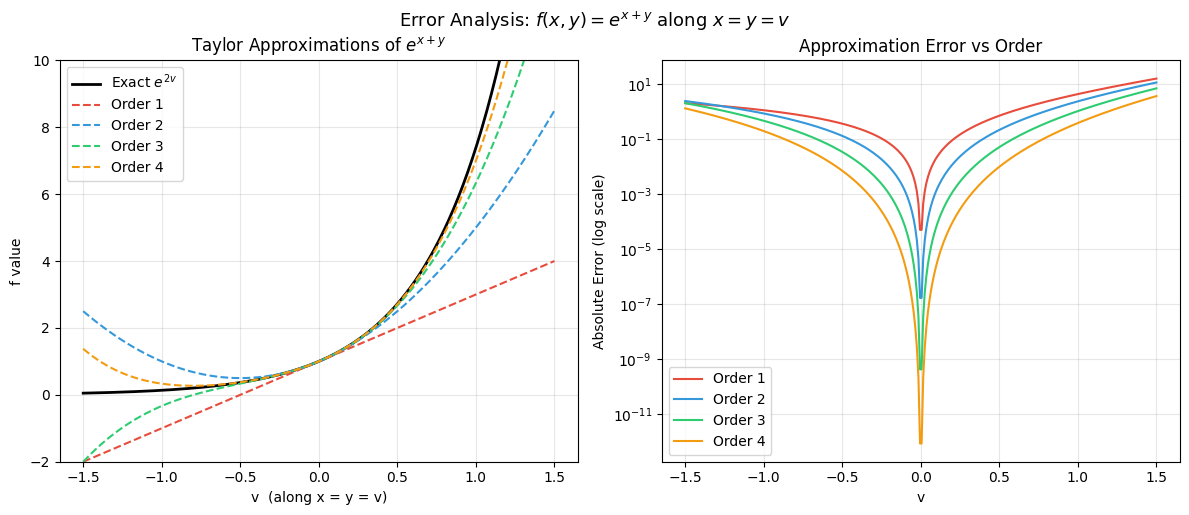

📊 Plot saved!


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Lambdify the exact function and its Taylor approximations
f_exact_sym = exp(x + y)

orders = [1, 2, 3, 4]
taylor_polys = {o: multivariable_taylor(f_exact_sym, x, y, 0, 0, o) for o in orders}

# Convert to numpy functions along diagonal x = y = v
v_vals = np.linspace(-1.5, 1.5, 300)

f_num = lambda v: np.exp(2 * v)   # exact: e^(x+y) with x=y=v

plt.figure(figsize=(12, 5))

# Left: Function values
plt.subplot(1, 2, 1)
plt.plot(v_vals, f_num(v_vals), 'k-', linewidth=2, label='Exact $e^{2v}$')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for o, c in zip(orders, colors):
    T_num_func = sp.lambdify((x, y), taylor_polys[o], 'numpy')
    approx_vals = T_num_func(v_vals, v_vals)
    plt.plot(v_vals, approx_vals, linestyle='--', color=c, label=f'Order {o}')

plt.ylim(-2, 10)
plt.xlabel('v  (along x = y = v)')
plt.ylabel('f value')
plt.title('Taylor Approximations of $e^{x+y}$')
plt.legend()
plt.grid(True, alpha=0.3)

# Right: Absolute error
plt.subplot(1, 2, 2)
exact_vals = f_num(v_vals)
for o, c in zip(orders, colors):
    T_num_func = sp.lambdify((x, y), taylor_polys[o], 'numpy')
    approx_vals = T_num_func(v_vals, v_vals)
    error = np.abs(exact_vals - approx_vals)
    plt.semilogy(v_vals, error + 1e-15, linestyle='-', color=c, label=f'Order {o}')

plt.xlabel('v')
plt.ylabel('Absolute Error (log scale)')
plt.title('Approximation Error vs Order')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Error Analysis: $f(x,y) = e^{x+y}$ along $x=y=v$', y=1.02, fontsize=13)
plt.savefig('taylor_error.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 Plot saved!")

## 🔹 Step 4: 3D Visualization — Exact vs Taylor Surface

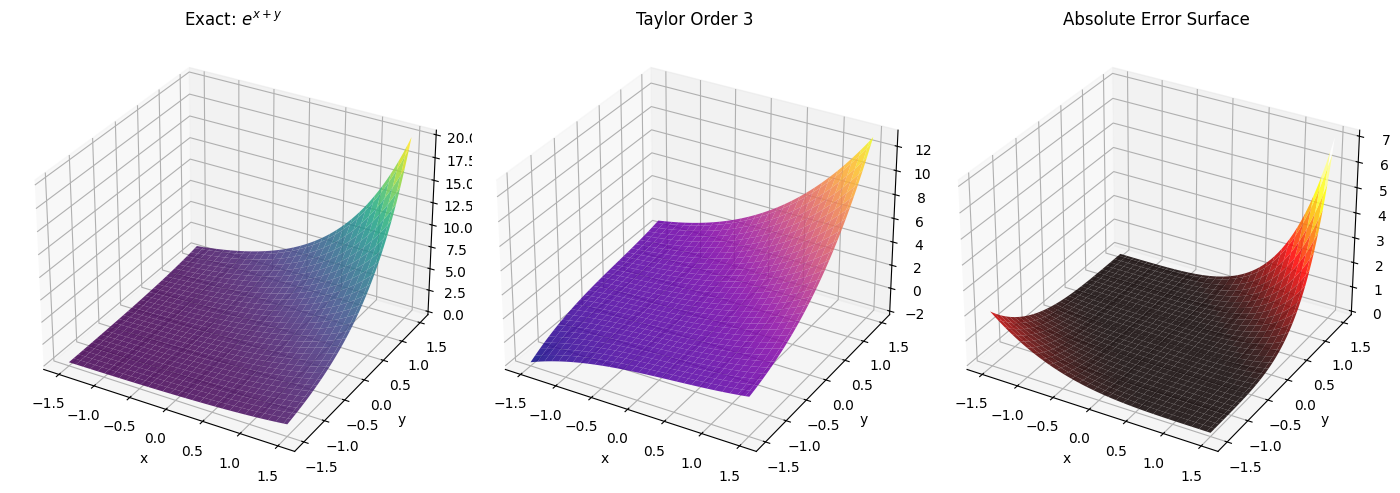

📊 3D plots saved!


In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Create grid
x_vals = np.linspace(-1.5, 1.5, 60)
y_vals = np.linspace(-1.5, 1.5, 60)
X, Y = np.meshgrid(x_vals, y_vals)

# Exact surface
Z_exact = np.exp(X + Y)

# Order-3 Taylor approximation
T3 = taylor_polys[3]
T3_func = sp.lambdify((x, y), T3, 'numpy')
Z_approx = T3_func(X, Y)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X, Y, Z_exact, cmap='viridis', alpha=0.85)
ax1.set_title('Exact: $e^{x+y}$')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X, Y, Z_approx, cmap='plasma', alpha=0.85)
ax2.set_title('Taylor Order 3')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('f')

ax3 = fig.add_subplot(133, projection='3d')
Z_error = np.abs(Z_exact - Z_approx)
ax3.plot_surface(X, Y, Z_error, cmap='hot', alpha=0.85)
ax3.set_title('Absolute Error Surface')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('|Error|')

plt.tight_layout()
plt.savefig('taylor_3d.png', dpi=120, bbox_inches='tight')
plt.show()
print("📊 3D plots saved!")

## 🔹 Step 5: Numerical Accuracy Table

In [10]:
print(f"{'Point (x,y)':<15} {'Exact':>12} {'Order1':>12} {'Order2':>12} {'Order3':>12} {'Error(O3)':>12}")
print("-" * 75)

test_points = [(0.1, 0.1), (0.5, 0.5), (1.0, 0.5), (1.0, 1.0), (-0.5, 0.3)]

for xv, yv in test_points:
    exact_val = float(np.exp(xv + yv))
    approx_vals = [float(sp.lambdify((x, y), taylor_polys[o], 'numpy')(xv, yv)) for o in [1, 2, 3]]
    error_o3 = abs(exact_val - approx_vals[2])
    print(f"({xv:+.1f}, {yv:+.1f}){'':<5} {exact_val:>12.6f} {approx_vals[0]:>12.6f} {approx_vals[1]:>12.6f} {approx_vals[2]:>12.6f} {error_o3:>12.2e}")

print()
print("✅ Higher order → smaller error, especially near the expansion point (0,0).")

Point (x,y)            Exact       Order1       Order2       Order3    Error(O3)
---------------------------------------------------------------------------
(+0.1, +0.1)          1.221403     1.200000     1.220000     1.221333     6.94e-05
(+0.5, +0.5)          2.718282     2.000000     2.500000     2.666667     5.16e-02
(+1.0, +0.5)          4.481689     2.500000     3.625000     4.187500     2.94e-01
(+1.0, +1.0)          7.389056     3.000000     5.000000     6.333333     1.06e+00
(-0.5, +0.3)          0.818731     0.800000     0.820000     0.818667     6.41e-05

✅ Higher order → smaller error, especially near the expansion point (0,0).


---
# 📝 Summary

| Concept | Key Formula |
|---|---|
| Homogeneous function of degree n | $f(tx, ty) = t^n f(x,y)$ |
| Euler's Theorem (2 variables) | $x f_x + y f_y = n f$ |
| Euler's Theorem (3 variables) | $x f_x + y f_y + z f_z = n f$ |
| Multivariable Taylor (around origin) | $f \approx f_0 + xf_x + yf_y + \frac{1}{2}(x^2 f_{xx} + 2xy f_{xy} + y^2 f_{yy}) + \cdots$ |
| Error decreases with | Higher order terms & proximity to expansion point |

---

---
# ✏️ Assignment Questions

Answer the following questions using Python/SymPy. Show all steps and verify your results analytically where possible.

---

### Q1. Homogeneity Check & Euler's Theorem
Given the function:
$$f(x, y) = \frac{x^2 y^2}{x^3 + y^3}$$

a) Check whether $f(x, y)$ is homogeneous. If yes, find its degree.  
b) Compute the partial derivatives $\dfrac{\partial f}{\partial x}$ and $\dfrac{\partial f}{\partial y}$.  
c) Verify Euler's Theorem: $x f_x + y f_y = n f$.

---

### Q2. Three-Variable Euler's Theorem
Given:
$$f(x, y, z) = \frac{x^4 + y^4 + z^4}{x^2 y + y^2 z + z^2 x}$$

a) Determine the degree of homogeneity.  
b) Verify Euler's Theorem for three variables: $x f_x + y f_y + z f_z = n f$.  
c) Evaluate LHS and RHS numerically at the point $(1, 2, 3)$ and confirm they match.

---

### Q3. Multivariable Taylor Series
Compute the Taylor series of:
$$f(x, y) = e^{x} \sin(y)$$

around the point $(0, 0)$ up to the **4th order**.

a) Write out the Taylor polynomial.  
b) Plot the exact function and its Taylor approximation (orders 2, 3, 4) along the line $y = x$ for $x \in [-2, 2]$.  
c) Tabulate the absolute error at points $(0.1, 0.1)$, $(0.5, 0.5)$, and $(1.0, 1.0)$ for each order.

---

### Q4. Taylor Series at a Non-Origin Point
Expand:
$$f(x, y) = \sqrt{x^2 + y^2}$$

as a Taylor series around the point $(3, 4)$ up to the **2nd order**.

a) Compute all required partial derivatives at $(3, 4)$.  
b) Write the Taylor polynomial.  
c) Compare the approximation with the exact value at $(3.1, 4.2)$ and compute the percentage error.

---

### Q5. Combined Problem — Homogeneity + Taylor
Let:
$$f(x, y) = x^2 \ln\!\left(\frac{y}{x}\right)$$

a) Show that $f(x, y)$ is homogeneous of degree 2.  
b) Verify Euler's Theorem.  
c) Compute the 2nd-order Taylor series of $f(x, y)$ around $(1, 1)$.  
d) **Bonus:** Create a 3D surface plot comparing the exact function and its Taylor approximation over the region $[0.5, 2] \times [0.5, 2]$. Label the error regions clearly.

---
> 💡 **Tip:** Use `check_homogeneity()`, `verify_eulers_theorem()`, and `multivariable_taylor()` functions defined above as starting points for your solutions.

In [11]:
# ── Q.1 To do ──
# Define your function here
# f_q1 = ...

# a) Check homogeneity

# b) Partial derivatives

# c) Verify Euler's Theorem


In [12]:
# ── Q2 To do ──


In [13]:
# ── Q3 To do ──


In [14]:
# ── Q4 To do ──


In [15]:
# ── Q5 To do ──
